# 1. Introduction
### Discover hidden customer segments using unsupervised learning.
- Identify patterns in customer behavior
- Group similar customers
- Provide actionable insights

# Dataset Overview

## People

- **ID**: Customer's unique identifier  
- **Year_Birth**: Customer's birth year  
- **Education**: Customer's education level  
- **Marital_Status**: Customer's marital status  
- **Income**: Customer's yearly household income  
- **Kidhome**: Number of children in customer's household  
- **Teenhome**: Number of teenagers in customer's household  
- **Dt_Customer**: Date of customer's enrollment with the company  
- **Recency**: Number of days since customer's last purchase  
- **Complain**: `1` if the customer complained in the last 2 years, `0` otherwise  

---

## Products

- **MntWines**: Amount spent on wine in the last 2 years  
- **MntFruits**: Amount spent on fruits in the last 2 years  
- **MntMeatProducts**: Amount spent on meat products in the last 2 years  
- **MntFishProducts**: Amount spent on fish products in the last 2 years  
- **MntSweetProducts**: Amount spent on sweet products in the last 2 years  
- **MntGoldProds**: Amount spent on gold products in the last 2 years  

---

## Promotion

- **NumDealsPurchases**: Number of purchases made with a discount  
- **AcceptedCmp1**: `1` if the customer accepted the offer in the 1st campaign, `0` otherwise  
- **AcceptedCmp2**: `1` if the customer accepted the offer in the 2nd campaign, `0` otherwise  
- **AcceptedCmp3**: `1` if the customer accepted the offer in the 3rd campaign, `0` otherwise  
- **AcceptedCmp4**: `1` if the customer accepted the offer in the 4th campaign, `0` otherwise  
- **AcceptedCmp5**: `1` if the customer accepted the offer in the 5th campaign, `0` otherwise  
- **Response**: `1` if the customer accepted the offer in the last campaign, `0` otherwise  

---

## Place

- **NumWebPurchases**: Number of purchases made through the company’s website  
- **NumCatalogPurchases**: Number of purchases made using a catalogue  
- **NumStorePurchases**: Number of purchases made directly in stores  
- **NumWebVisitsMonth**: Number of visits to the company’s website in the last month

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv("../data/raw/marketing_campaign.csv",sep="\t")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
df.shape

(2240, 29)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [6]:
df.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [7]:
df.duplicated().sum()

0

- There are 0 duplicates

In [8]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [9]:
df["Age"] = 2026 - df["Year_Birth"]
df = df.drop(columns=['Year_Birth'])

Convert the year of born to Age

### Age distribution

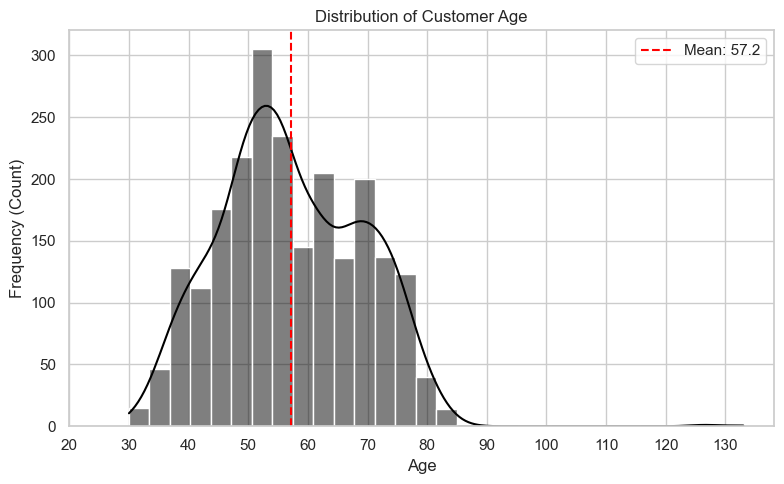

In [10]:
sns.set_theme(style="whitegrid") 

plt.figure(figsize=(8, 5))

ax = sns.histplot(df["Age"], bins=30, kde=True, color="black")

plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Frequency (Count)")
plt.xticks(range(20,140,10))

mean_val = df["Age"].mean()
plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.1f}')
plt.legend()

plt.tight_layout()
plt.show()


In [11]:
outlairs = df[df['Age']>100]
outlairs['Age'].value_counts()


Age
126    1
133    1
127    1
Name: count, dtype: int64

Age has some extrem values like >100

In [12]:
# Keep only rows where Age is 100 or less
df = df[df['Age'] <= 100]
outlairs = df[df['Age']>100]
outlairs['Age'].value_counts()


Series([], Name: count, dtype: int64)

### Distribution of Education

Text(0, 0.5, 'Count')

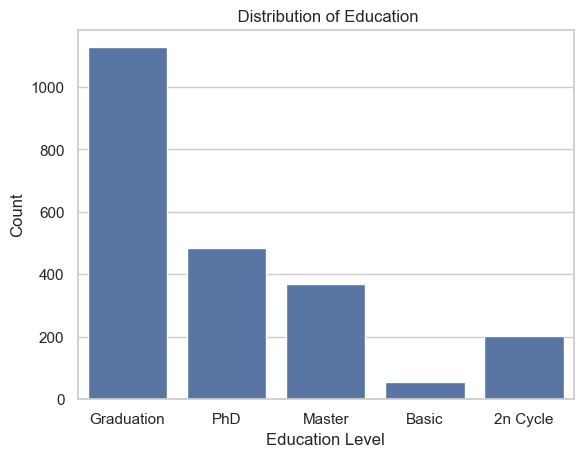

In [13]:
sns.countplot(data=df,x='Education')
plt.title(" Distribution of Education")
plt.xlabel("Education Level")
plt.ylabel("Count")


- most are graduate
- some has PhD adn Master 
- some are undergrate

In [14]:
edu_map = {
    'Basic': 'Undergraduate',
    '2n Cycle': 'Undergraduate',
    'Graduation': 'Graduate',
    'Master': 'Postgraduate',
    'PhD': 'Postgraduate'
}

df['Education_Group'] = df['Education'].replace(edu_map)

print(df['Education_Group'].value_counts())


Education_Group
Graduate         1127
Postgraduate      855
Undergraduate     255
Name: count, dtype: int64


In [15]:
df.drop(columns=["Education"], inplace=True)

compain to 3 group help reduce sparsity

### Distribution of Marital Status

Text(0, 0.5, 'Number of Customers')

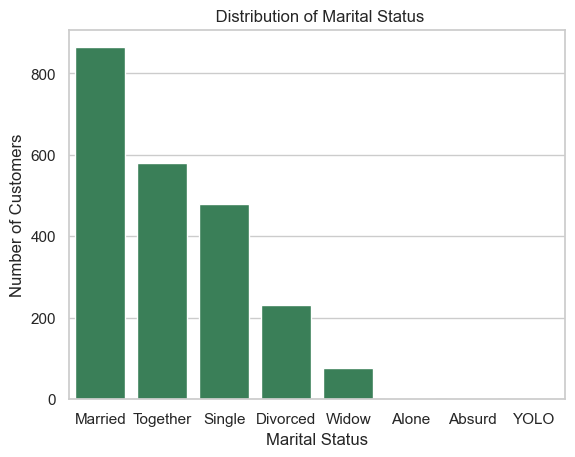

In [16]:
order = df['Marital_Status'].value_counts().index
sns.countplot(data=df, x='Marital_Status', order=order, color="seagreen")
plt.title(" Distribution of Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Number of Customers")



In [17]:
df['Marital_Status'].value_counts()

Marital_Status
Married     864
Together    579
Single      479
Divorced    231
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

- Most customers are Married.
- Together and Single are also common.
- Divorced and Widow are fewer.
- Absurd and YOLO appear as rare/inconsistent categories.

In [18]:
df['Marital_Status'] = df['Marital_Status'].replace('Alone','Single')
df = df[~df['Marital_Status'].isin(['Absurd', 'YOLO'])]

# Verify the result
print(df['Marital_Status'].value_counts())


Marital_Status
Married     864
Together    579
Single      482
Divorced    231
Widow        77
Name: count, dtype: int64


convert alone to single and remove rare value

In [19]:
df["Marital_Status"] = df["Marital_Status"].replace({
    "Married": "Partnered",
    "Together": "Partnered"
})
print(df['Marital_Status'].value_counts())


Marital_Status
Partnered    1443
Single        482
Divorced      231
Widow          77
Name: count, dtype: int64


- Make Married and Together as Partnered 

### Distribution of Customer Annual Income

Text(0.5, 0, 'Annual Income')

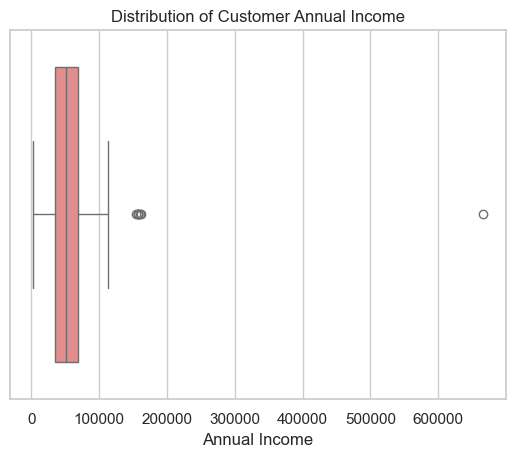

In [20]:
sns.boxplot(x=df["Income"], color="lightcoral")
plt.title("Distribution of Customer Annual Income")
plt.xlabel("Annual Income")


- there are some exteme values maybe they billioners
- need scaling


In [21]:
df[df['Income']>600000]

,ID,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Education_Group
2233,9432,Partnered,666666.0,1,0,02-06-2013,23,9,14,18,...,0,0,0,0,0,3,11,0,49,Graduate


- For clustering algorithms like K-Means, this can be a problem so remove it

In [22]:
df = df.dropna(subset=["Income"])     
df = df[df["Income"] < 600000]
df["Income"].max()

162397.0

missing data was small(1%) and income is an important feature for customer segmentation, these rows were removed rather than imputed.extreme income values above 600,000 were removed to reduce the influence of outliers on distance-based clustering algorithms

### Distribution of Child at Home

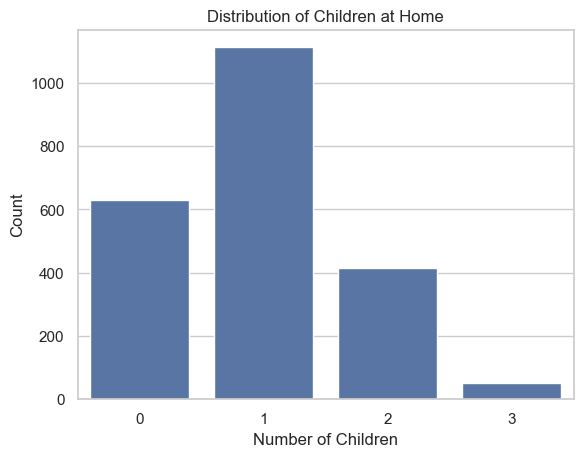

In [23]:
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

sns.countplot(x="Total_Children", data=df)
plt.title("Distribution of Children at Home")
plt.xlabel("Number of Children")
plt.ylabel("Count")

df.drop(columns=["Kidhome", "Teenhome"], inplace=True)



- decide reduce feature by adding teen and child into one like Total_Children

### Distribution of customer's last purchase

Text(0, 0.5, 'Customer Count')

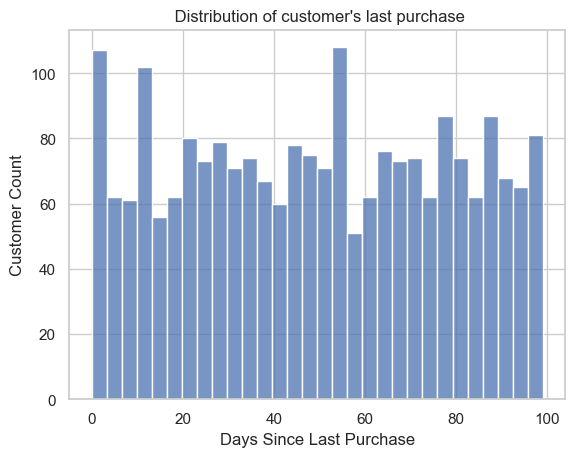

In [24]:
sns.histplot(df["Recency"], bins=30)
plt.title(" Distribution of customer's last purchase")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Customer Count")


it show how the last purachas has take place

### 

Text(0, 0.5, 'Number of Customers')

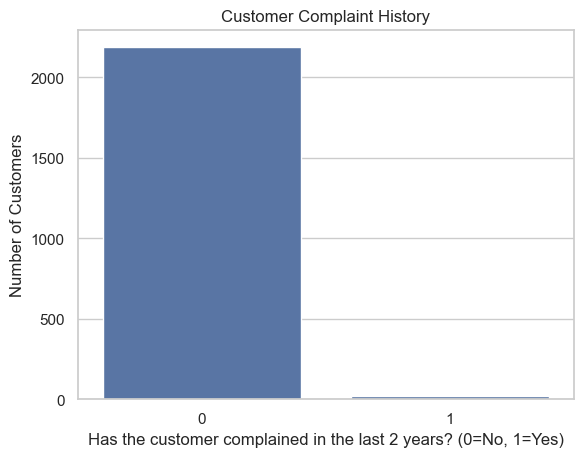

In [25]:
sns.countplot(data = df, x='Complain')
plt.title("Customer Complaint History")
plt.xlabel("Has the customer complained in the last 2 years? (0=No, 1=Yes)")
plt.ylabel("Number of Customers")


In [26]:
df['Complain'].value_counts()

Complain
0    2188
1      20
Name: count, dtype: int64

Most of the customers are very happy,out of 2188 only 20 customers has complain

### Distributions of Products Features

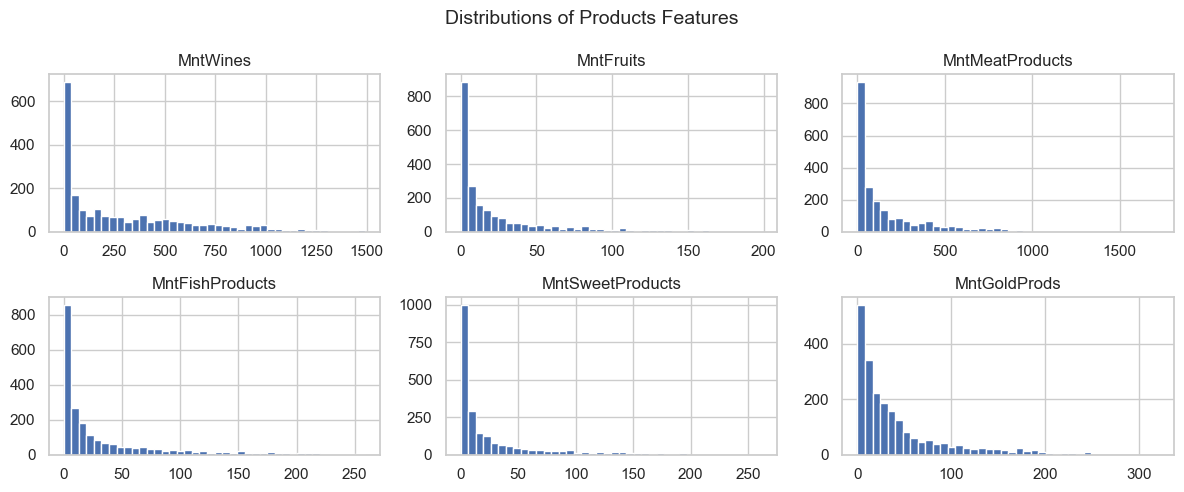

In [27]:
Products = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]

df[Products].hist(bins=40, figsize=(12, 5), layout=(2, 3))
plt.suptitle("Distributions of Products Features",  fontsize=14)
plt.tight_layout()
plt.show()

This helps to identify the spendings on Products 

use log transform beacause it has right skwed so in cluster like distance-based clustering (like K-Means) causes problems because large values dominate the distance.

### Distribution of Purchases Made with Discounts

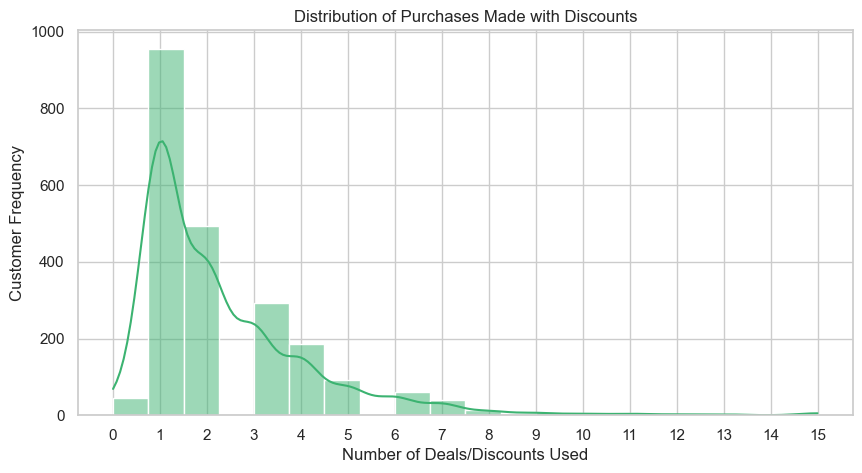

In [28]:
plt.figure(figsize=(10, 5))
sns.histplot(df["NumDealsPurchases"], bins=20, kde=True, color="mediumseagreen")
plt.title("Distribution of Purchases Made with Discounts")
plt.xlabel("Number of Deals/Discounts Used")
plt.ylabel("Customer Frequency")
plt.xticks(range(0,16))
plt.show()


- most are purchased in like in 1,2 deals offer, we can also see there is deal hunders

In [29]:
df["Total_Campaign_Accepted"] = ( df["AcceptedCmp1"] + df["AcceptedCmp2"] + df["AcceptedCmp3"] + df["AcceptedCmp4"] + df["AcceptedCmp5"])

df.drop(columns=["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5"], inplace=True)

In [30]:
df.columns

Index(['ID', 'Marital_Status', 'Income', 'Dt_Customer', 'Recency', 'MntWines',
       'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Z_CostContact', 'Z_Revenue', 'Response', 'Age',
       'Education_Group', 'Total_Children', 'Total_Campaign_Accepted'],
      dtype='object')

- Avoid adding **Response** it can act like an Target
- Clustering groups customers based on behavior, and **Response** helps us understand which groups respond to marketing campaigns.

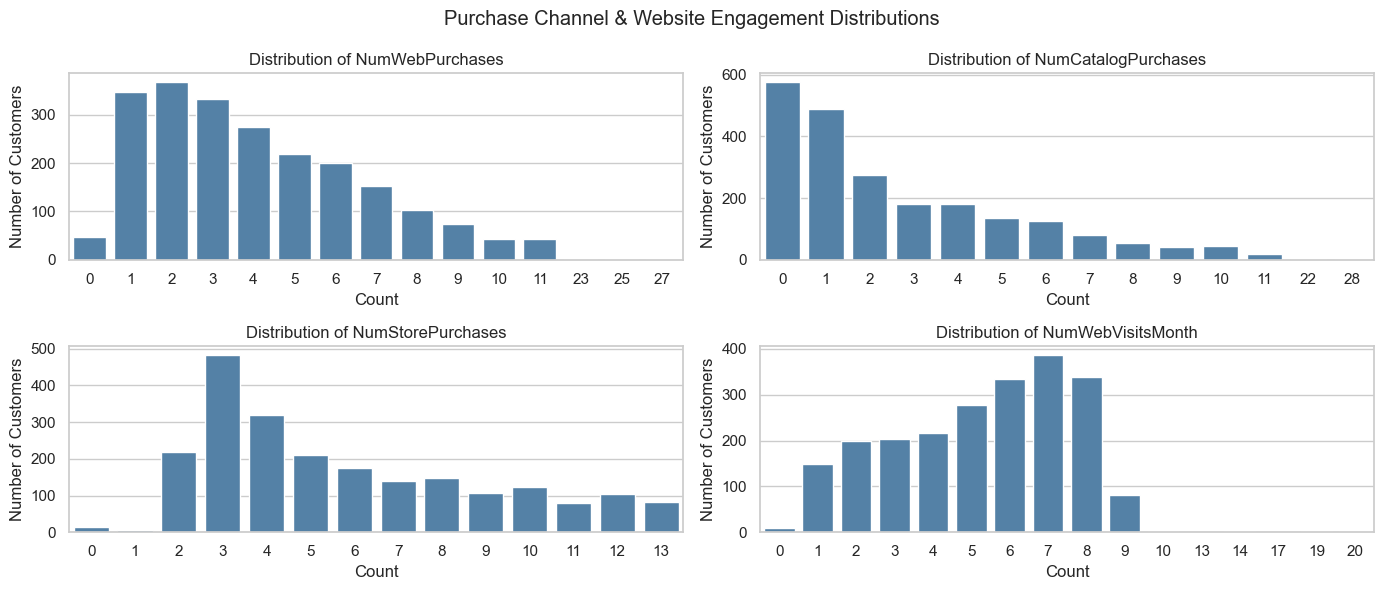

In [31]:
purchase_cols = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']

fig, axes = plt.subplots(2, 2, figsize=(14, 6))

axes = axes.flatten()

for i, col in enumerate(purchase_cols):
    sns.countplot(data=df, x=col, ax=axes[i], color="steelblue")
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel("Count")
    axes[i].set_ylabel("Number of Customers")

plt.suptitle("Purchase Channel & Website Engagement Distributions")
plt.tight_layout()
plt.show()


- its  help understand customer shopping behavior.
- Last chart shows Number of visits to company’s website in the last month
- show similar purachase pattern in purchases made through the company’s website and purchases made using a catalogue

In [32]:
unknown =  'Z_CostContact', 'Z_Revenue'

for i in unknown:
    print(df[i].value_counts())
    print(df[i].isna().sum())
    print('*'*30)

Z_CostContact
3    2208
Name: count, dtype: int64
0
******************************
Z_Revenue
11    2208
Name: count, dtype: int64
0
******************************


- Machine learning models need variation in data.
- But these columns have same value for all rows.
- They provide zero information for clustering.
- So removeing them.

In [33]:
df.drop(["Z_CostContact","Z_Revenue"], axis=1, inplace=True)

In [34]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

df["Customer_Tenure_Days"] = (df["Dt_Customer"].max() - df["Dt_Customer"]).dt.days

df["Customer_Tenure_Days"].head()

0    663
1    113
2    312
3    139
4    161
Name: Customer_Tenure_Days, dtype: int64

- Clustering algorithms cannot understand calendar meaning.
- Dates must be converted to numeric features.
- Customer_Tenure_Days very useful for clustering

### Prepare Data ready 
- Take only need column for final features

In [35]:
df.drop(["ID", "Dt_Customer", "Response"], axis=1, inplace=True)


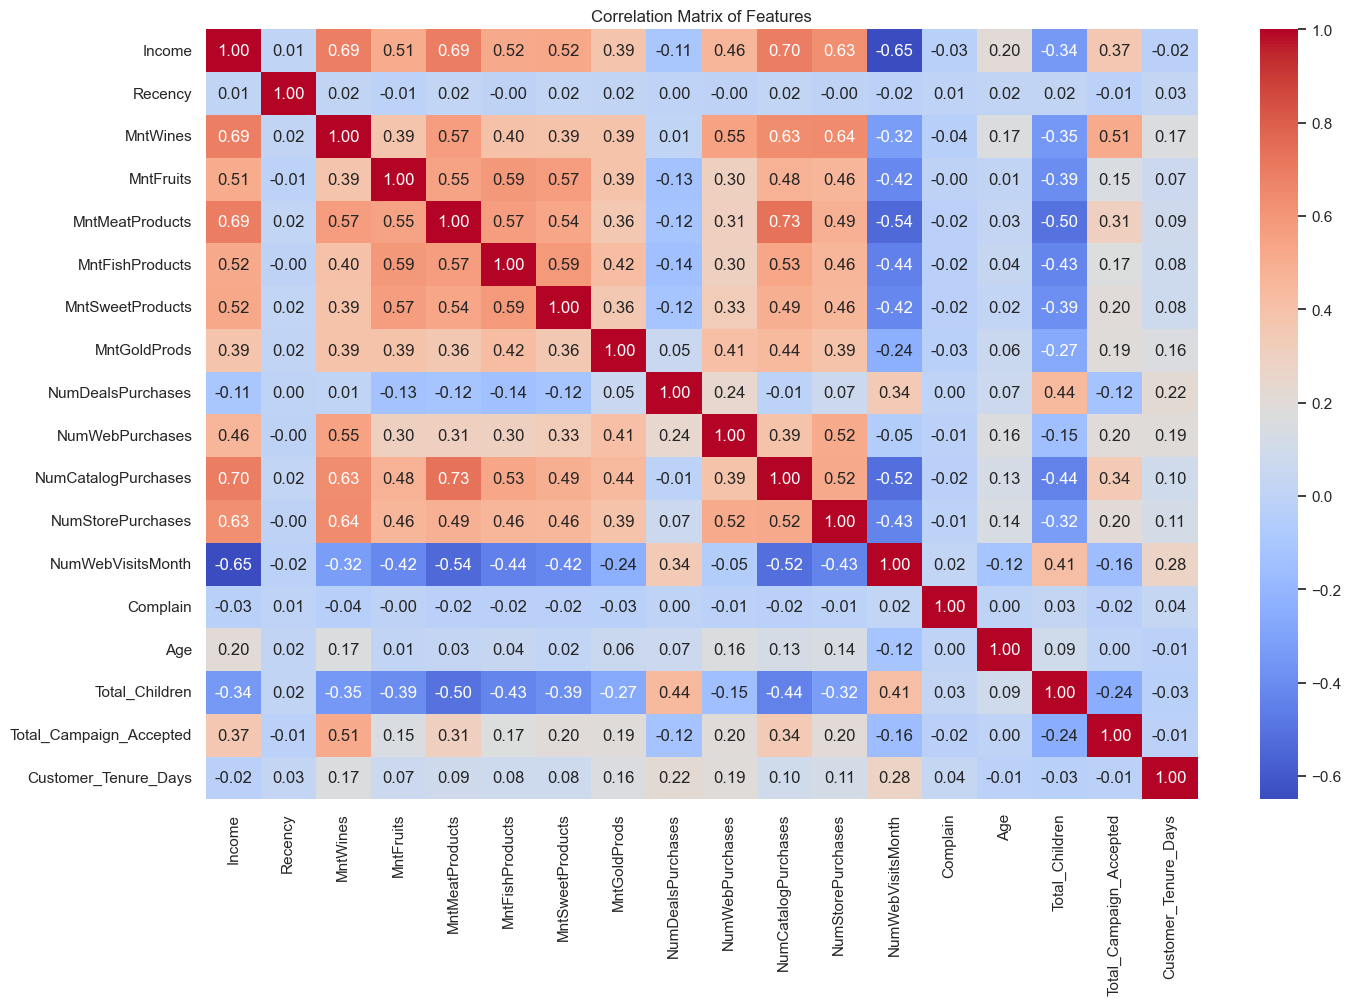

In [36]:
plt.figure(figsize=(16, 10))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix of Features")
plt.show()


## EDA Conclusion

Key findings before modelling:

- **Demographics:** Majority are graduates, aged 25-65, married, with 0-2 children.
- **Income:** Right-skewed (~median 51K); one extreme outlier (>600K) removed.
- **Spending:** All product columns are heavily right-skewed - log transform recommended before distance-based clustering.
- **Campaigns:** Low acceptance rate overall; aggregated into Total_Campaign_Accepted.
- **Recency & Tenure:** Evenly spread - useful for separating active from dormant customers.

> Response is excluded from clustering and will be used to evaluate segment quality.

## Feature Engineering And Preprocesing

### Total_Purchases

In [37]:
df['Total_Purchases'] = df[['NumWebPurchases','NumCatalogPurchases','NumStorePurchases','NumDealsPurchases']].sum(axis=1)


Total_Purchases was created to represent the overall number of purchases made by a customer across different channels.It may be correlated with individual purchase channel variables.

### Total_Spending

In [38]:
df['Total_Spending'] = df[['MntWines','MntFruits','MntMeatProducts', 'MntFishProducts','MntSweetProducts','MntGoldProds']].sum(axis=1)


A new feature Total_Spending was created by summing all product spending columns. This feature represents the overall spending behavior of each customer and helps capture the customer's total purchasing value, which can improve clustering performance.

### Spending_Per_Purchase

In [39]:
df['Spending_Per_Purchase'] = df['Total_Spending'] / (df['Total_Purchases'] + 1)


- It capture the average amount spent per transaction.

In [40]:
df.to_csv("../data/processed/marketing_data_cleaned.csv", index=False)

In [41]:
import sys
import os

sys.path.append(os.path.abspath(".."))


from src.preprocessing import remove_duplicates

if df.duplicated().any():
    df = remove_duplicates(df)

Remove Duplicates if there is any.

In [42]:

df = pd.get_dummies(df, drop_first=True, dtype=int)


convert all categorical columns, Because this must be encoded before clustering

In [43]:
df.head()

,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,...,Total_Campaign_Accepted,Customer_Tenure_Days,Total_Purchases,Total_Spending,Spending_Per_Purchase,Marital_Status_Partnered,Marital_Status_Single,Marital_Status_Widow,Education_Group_Postgraduate,Education_Group_Undergraduate
0,58138.0,58,635,88,546,172,88,88,3,8,...,0,663,25,1617,62.192308,0,1,0,0,0
1,46344.0,38,11,1,6,2,1,6,2,1,...,0,113,6,27,3.857143,0,1,0,0,0
2,71613.0,26,426,49,127,111,21,42,1,8,...,0,312,21,776,35.272727,1,0,0,0,0
3,26646.0,26,11,4,20,10,3,5,2,2,...,0,139,8,53,5.888889,1,0,0,0,0
4,58293.0,94,173,43,118,46,27,15,5,5,...,0,161,19,422,21.100000,1,0,0,1,0


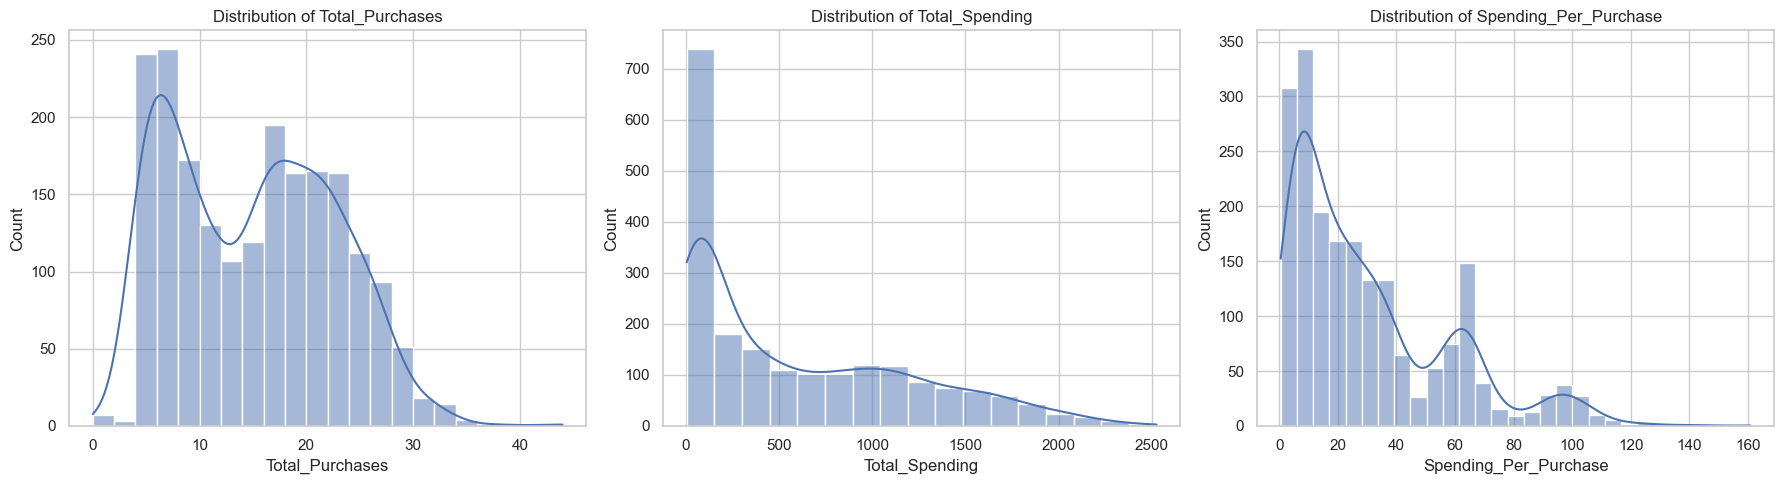

In [44]:
cols = ['Total_Purchases', 'Total_Spending', 'Spending_Per_Purchase']

plt.figure(figsize=(18, 5))

for i, col in enumerate(cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

- check any feature need log transform
- look good for `'Total_Purchases'` and `'Spending_Per_Purchase'`
- need for `Total_Spending` but we not using this in modeling it only created for create feature of `Spending_Per_Purchase`
- because it will be highly correlated

### Apply Log Transform 
- use np.log1p() because some values are 0.
- log transform fixes skewness


In [45]:
cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]

df[cols] = np.log1p(df[cols])

In [46]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

X_scaled


,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,...,Total_Campaign_Accepted,Customer_Tenure_Days,Total_Purchases,Total_Spending,Spending_Per_Purchase,Marital_Status_Partnered,Marital_Status_Single,Marital_Status_Widow,Education_Group_Postgraduate,Education_Group_Undergraduate
0,0.282314,0.309737,0.983753,1.431674,1.389459,1.580396,1.408062,1.068707,0.349582,1.411550,...,-0.440610,1.538222,1.320941,1.676143,1.160031,-1.339875,1.895436,-0.188689,-0.785649,-0.359766
1,-0.263294,-0.381245,-1.214060,-0.992064,-1.397875,-0.858639,-0.973827,-0.905995,-0.169745,-1.123394,...,-0.440610,-1.181901,-1.160655,-0.963205,-0.987949,-1.339875,1.895436,-0.188689,-0.785649,-0.359766
2,0.905686,-0.795835,0.763205,1.063458,0.460621,1.318853,0.530991,0.503774,-0.689072,1.411550,...,-0.440610,-0.197711,0.798500,0.280110,0.168815,0.746338,-0.527583,-0.188689,-0.785649,-0.359766
3,-1.174551,-0.795835,-1.214060,-0.406935,-0.695300,-0.077074,-0.538837,-1.025710,-0.169745,-0.761259,...,-0.440610,-1.053314,-0.899435,-0.920046,-0.913137,0.746338,-0.527583,-0.188689,-0.785649,-0.359766
4,0.289484,1.553506,0.266254,0.981826,0.413997,0.796508,0.682334,-0.263990,1.388236,0.325146,...,-0.440610,-0.944509,0.537279,-0.307518,-0.353044,0.746338,-0.527583,-0.188689,1.272833,-0.359766
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2002,-1.166686,0.033344,-1.597762,-0.992064,-1.397875,-0.685588,-0.398801,-1.340598,-0.689072,-1.485529,...,-0.440610,1.627244,-1.421876,-0.971505,-0.967960,-1.339875,1.895436,-0.188689,-0.785649,-0.359766
2003,0.425030,-0.104852,1.044682,0.981826,0.689218,0.743003,1.590359,1.864569,-0.169745,1.773685,...,-0.440610,0.143540,0.406669,1.217992,1.468838,0.746338,-0.527583,-0.188689,-0.785649,-0.359766
2004,0.228789,1.449859,1.181457,1.050557,0.801138,0.583781,0.200837,0.082600,-0.689072,-0.761259,...,1.030777,-0.974183,0.537279,1.051995,1.154791,-1.339875,-0.527583,-0.188689,-0.785649,-0.359766
2005,0.796139,-1.417720,0.765792,0.758192,0.792277,1.123925,0.746209,0.787962,-0.169745,0.687280,...,-0.440610,-0.969237,1.059720,0.391328,0.163376,0.746338,-0.527583,-0.188689,1.272833,-0.359766


# Modeling

## Reducing Dimentionality

In [47]:
from src.clustering import apply_pca, compute_elbow, compute_silhouette, run_kmeans

X_pca, pca = apply_pca(X_scaled)    # X_pca has fit transform values and pca is model
print("Components retained:", pca.n_components_)


Components retained: 15


In [48]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
print(cumulative_variance)

[0.35564988 0.43976546 0.51151332 0.57672714 0.62185055 0.66313027
 0.70178779 0.74025988 0.77509609 0.80401713 0.83210559 0.85738927
 0.8777405  0.89641243 0.91360078]


In [49]:
X_pca.shape

(2007, 15)

- These 15 components capture ~91% of the information in the original dataset.

# Clustering Experiments with KMeans

- n_init gives a better quality model (finds the "best" clusters)
- while random_state gives consistency (get the same "best" every time).

In [50]:
from src.evaluation import get_davies_bouldin
from src.clustering import compute_silhouette
from sklearn.cluster import KMeans, AgglomerativeClustering

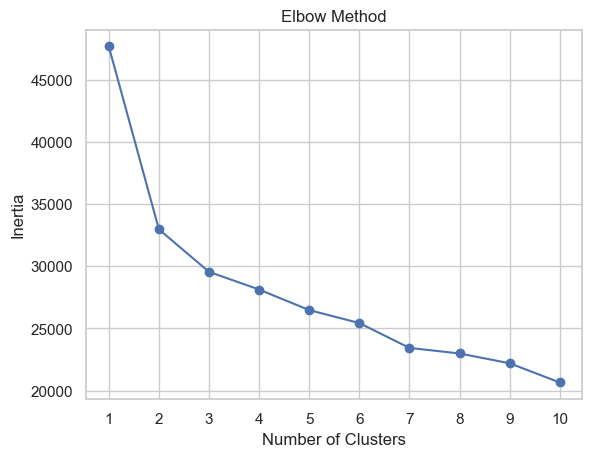

In [51]:
wcss = compute_elbow(X_pca)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.xticks(range(1,11))
plt.savefig('../outputs/reports/elbow_plot.png', dpi=150, bbox_inches='tight')
plt.show()


- Based on Elbow Method choose K=3

### KMeans silhouette_score plot
- used for Visual impact and why choose K=3

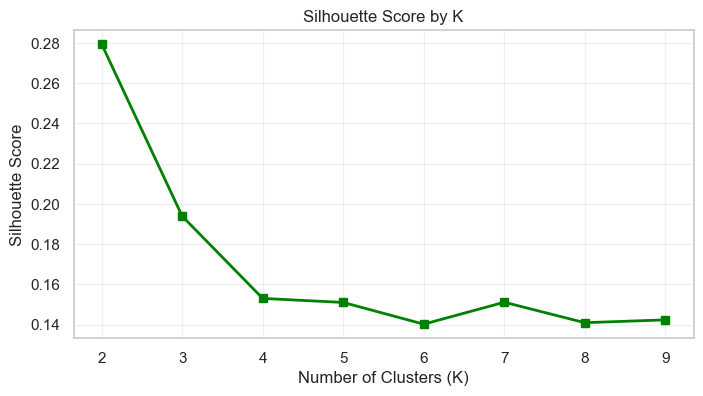

In [52]:
from src.clustering import plot_silhouette_scores
scores = plot_silhouette_scores(X_pca)

- from this we can see 2 is best
- but 2 only divede into 2 group its not much helpful
- so then better option is 3 so choose K=3

### compute_silhouette scores

In [53]:
scores = compute_silhouette(X_pca, KMeans, random_state=42, n_init=10)

for k, score in scores.items():
    print(f"K={k}, Silhouette Score={score:.3f}")

K=3, Silhouette Score=0.194
K=4, Silhouette Score=0.153
K=5, Silhouette Score=0.151
K=6, Silhouette Score=0.140


- -1 → very bad clustering
- 0 → overlapping clusters
-  1 → perfect clusters

| Score   | Meaning            |
| ------- | ------------------ |
| 0.7+    | excellent clusters |
| 0.5     | good               |
| 0.3     | acceptable         |
| 0.1–0.2 | weak but usable    |
| <0.1    | poor               |


This means clusters exist but separation is not very strong.


In [54]:
model, clusters = run_kmeans(X_pca, n_clusters=3)

df["KMeans_Cluster"] = clusters

df["KMeans_Cluster"].value_counts()

KMeans_Cluster
0    844
1    587
2    576
Name: count, dtype: int64

- Save the KMeans_Cluster in features

### Check for davies_bouldin_score

In [55]:
db_kmeans = get_davies_bouldin(X_pca, clusters,  "KMeans")

  KMeans DB Index: 1.8997 


- Based on the best, Silhouette Score=0.194 and Elbow Method choose K=3
-   KMeans DB Score: 1.8997  (lower is better)


### 2D scatter plot

Text(0.5, 1.0, 'Customer Segments')

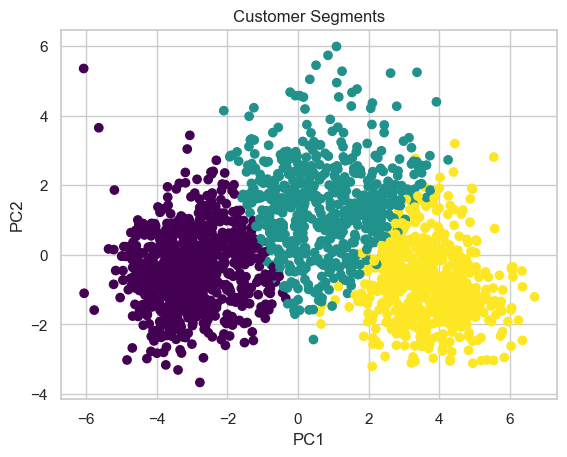

In [56]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segments")

### Customer Segments — PCA Visualization

The scatter plot shows three visually separable customer clusters in 2D PCA space.

- **Cluster 0 (purple)** — spreads along the left side of PC1, indicating 
    likely lower spending or engagement
- **Cluster 1 (teal)** — occupies the center-upper region, representing
  a mid-range customer group
- **Cluster 2 (yellow)** — concentrated on the right side of PC1, tightly
  grouped, suggesting a more homogeneous high-value customer segment


# Hierarchical Clustering
## Method 2

In [57]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

## Dendrogram

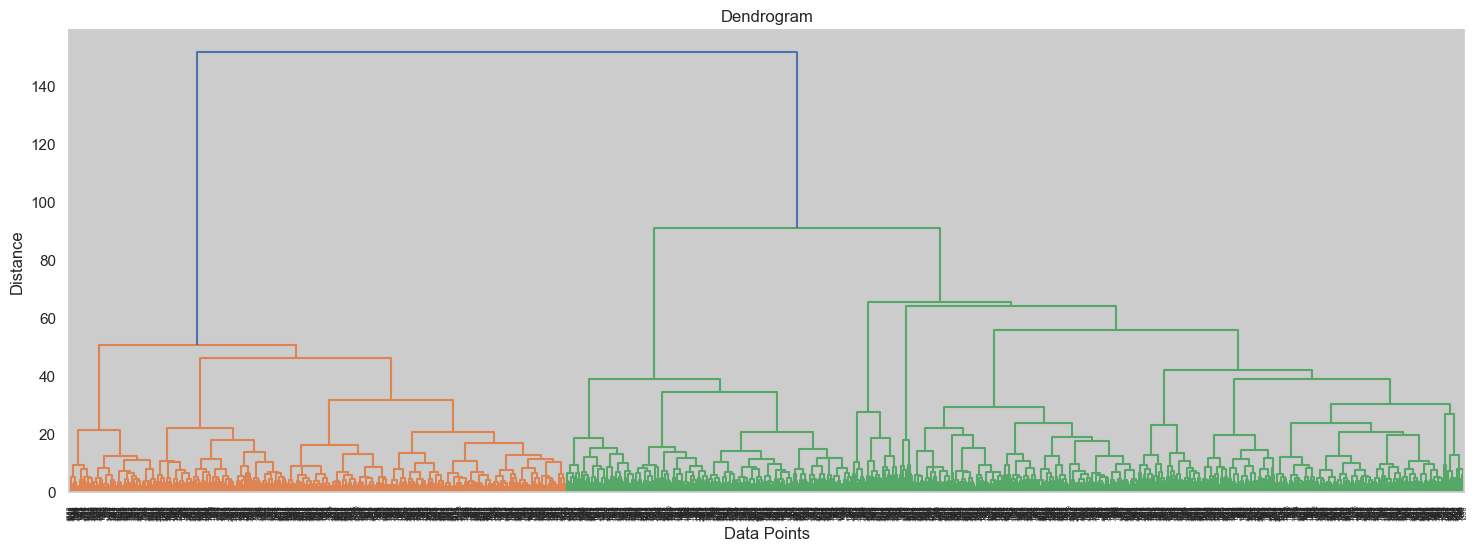

In [58]:
Z = linkage(X_pca, method='ward')

plt.figure(figsize=(18,6))
dendrogram(Z)

plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

- Choose to cut the line where 2nd line that comes after large one

In [60]:
hc_score = compute_silhouette(X_pca, AgglomerativeClustering, linkage='ward')

for k, score in hc_score.items():
    print(f"K={k}, Silhouette Score={score:.3f}")

K=3, Silhouette Score=0.158
K=4, Silhouette Score=0.171
K=5, Silhouette Score=0.177
K=6, Silhouette Score=0.124


- Based on K=5, Silhouette Score=0.177 and denderogram choose K=5

### davies_bouldin_score

In [66]:
print(get_davies_bouldin(X_pca, hc_labels, "AgglomerativeClustering"))

  AgglomerativeClustering DB Index: 1.9469 
1.9468908403030565


In [69]:
hc = AgglomerativeClustering(n_clusters=5, linkage='ward')

hc_labels = hc.fit_predict(X_pca)

df['HC_Cluster'] = hc_labels

KMeans optimal K=3 (silhouette peaks at 0.194)
Agglomerative optimal K=5 (silhouette peaks at 0.177)

Each algorithm identified a different optimal number of clusters,
which is expected as they use different approaches to form groups.
KMeans will be used as the final model for cluster interpretation
due to its higher silhouette score at its optimal K.

### Customer Segments — Hierarchical Clustering (K=5) Visualization


Text(0.5, 1.0, 'Customer Segments (Hierarchical Clustering)')

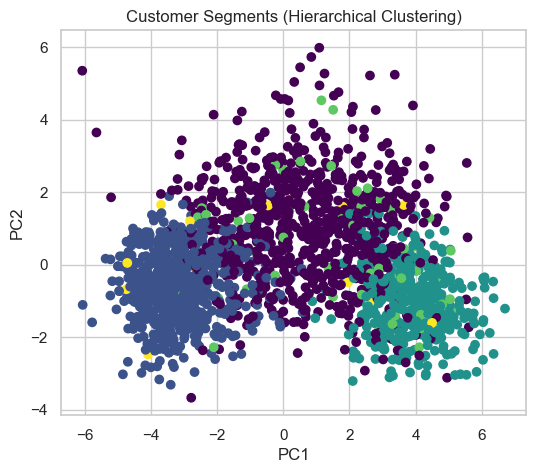

In [70]:
plt.figure(figsize=(6,5))

plt.scatter(X_pca[:,0], X_pca[:,1], c=hc_labels, cmap="viridis")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segments (Hierarchical Clustering)")

With K=5, the Hierarchical Clustering plot reveals **significant overlap**
between clusters, particularly in the central region. Unlike KMeans,
the boundaries here are much harder to distinguish visually.

Overall, the 5-cluster Agglomerative solution produces overlapping segments that are difficult to interpret meaningfully.
This visually confirms why **KMeans with K=3 is the better choice**
— cleaner boundaries, simpler interpretation, and stronger
silhouette score (0.194 vs 0.177).


## Cluster Evaluation — Model Comparison

### Silhouette Score Comparison

| K | KMeans | Agglomerative |
|---|--------|---------------|
| 3 | 0.194  | 0.158         |
| 4 | 0.153  | 0.171         |
| 5 | 0.151  | 0.177         |
| 6 | 0.140  | 0.124        |

 **Higher is better** (max = 1.0)

---

### Davies-Bouldin Index Comparison

| Model | DB Index |
|-------|----------|
| KMeans | 1.8997 |
| Agglomerative | 1.9469 |

 **Lower is better** (min = 0)

---


On the Davies-Bouldin Index, **KMeans (1.8997)** outperforms Agglomerative
Clustering (1.9469), meaning KMeans produces more compact and
well-separated clusters.

Visually, KMeans produces **cleaner cluster boundaries** while Agglomerative
with K=5 shows significant overlap and fragmentation in the PCA plot.

**KMeans with K=3 is chosen as the final model** — it achieves the highest
silhouette score, better DB Index, and cleaner visual separation,
making it the most suitable choice for customer segment interpretation.


## Create Cluster Profile Table

In [ ]:
cluster_profile = df.groupby('KMeans_Cluster').mean()
cluster_profile

,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,...,Customer_Tenure_Days,Total_Purchases,Total_Spending,Spending_Per_Purchase,Marital_Status_Partnered,Marital_Status_Single,Marital_Status_Widow,Education_Group_Postgraduate,Education_Group_Undergraduate,HC_Cluster
KMeans_Cluster,,,,,,,,,,,,,,,,,,,,,
0,34027.157583,48.949052,2.891871,1.142757,2.612406,1.360867,1.164205,2.176415,1.917062,1.875592,...,310.545024,7.286730,76.988152,8.698186,0.646919,0.228673,0.021327,0.357820,0.167062,0.822275
1,54916.902896,48.880750,5.692842,2.317966,4.582343,2.558642,2.269902,3.640633,3.862010,6.211244,...,409.419080,19.977853,636.976150,29.426471,0.647359,0.190801,0.045997,0.441227,0.068143,0.080068
2,75486.043403,49.317708,6.261210,3.791601,5.898846,4.200060,3.803007,3.945959,1.362847,5.215278,...,354.145833,20.833333,1353.956597,64.194845,0.630208,0.229167,0.041667,0.355903,0.085069,1.381944


### Cluster 0 — Low Value Customers
These customers have limited purchasing activity and low spending levels. They represent low-value or price-sensitive customers.
- Lowest income
- Few purchases
- Very low total spending
- Low spending per purchase

### Cluster 1 — Regular Customers
These customers show consistent purchasing behavior and moderate spending patterns, making them stable contributors to overall revenue.
- Medium income
- High purchase frequency
- Moderate spending
- Moderate spending per purchase

### Cluster 2 — Premium Customers
This cluster represents high-value customers who contribute significantly to revenue. Their high spending per purchase suggests premium purchasing behavior.
- Highest income
- High purchase frequency
- Extremely high total spending
- Highest spending per purchase

In [64]:
cluster_names = {
    0 : "Low Value Customers",
    1 : "Regular Customers",
    2 : "Regular Customers"
}

df['Cluster_Label'] = df['KMeans_Cluster'].map(cluster_names)

## Business Insights
- Premium customers generate the highest revenue despite being a smaller segment.
- Regular customers represent a stable revenue base with consistent purchasing patterns.
- Low-value customers show minimal engagement and may require targeted promotions.

In [65]:
df.to_csv("../outputs/clusters/dataset_with_clusters.csv", index=False)